<a href="https://colab.research.google.com/github/anyavaniprakash-spec/FTI-DSRP-Arms-Tranfers/blob/main/dsrp_Day_1-4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

UPLOADING DATA

# New Section

day 1

In [1]:
import pandas as pd
import csv
import io

In [2]:
url = 'https://raw.githubusercontent.com/frontiertechinstitute/datasets/main/Arms%20Transfers/arms_transfers_clean.csv'
df = pd.read_csv(url)

In [3]:
df.head()

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,2018; 2019; 2020; 2021,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,2007; 2008,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,2011; 2012,New,0.40,16.4,16.4


BASIC DATAFRAME FUNCTIONS

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9756 entries, 0 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       9756 non-null   object 
 1   Supplier                        9756 non-null   object 
 2   Year of order                   9756 non-null   int64  
 3   Number ordered                  9670 non-null   float64
 4   Weapon designation              9756 non-null   object 
 5   Weapon description              9756 non-null   object 
 6   Deliveries in the Year Range    9333 non-null   float64
 7   Year(s) of delivery             9333 non-null   object 
 8   status                          9756 non-null   object 
 9   SIPRI TIV per unit              9756 non-null   float64
 10  SIPRI TIV for total order       9756 non-null   float64
 11  SIPRI TIV of delivered weapons  9756 non-null   float64
dtypes: float64(5), int64(1), object(6)

,Year of order,Number ordered,Deliveries in the Year Range,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9756.000000,9670.000000,9333.000000,9756.000000,9756.000000,9756.000000
mean,1987.274703,156.860703,154.585664,7.443830,94.357230,83.811894
std,22.060454,987.060460,997.650698,23.468209,337.544437,303.717951
min,1940.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,0.240000,5.000000,4.200000
50%,1986.000000,12.000000,12.000000,1.000000,18.000000,16.000000
75%,2008.000000,60.000000,57.000000,5.000000,56.000000,52.575000
max,2025.000000,50000.000000,50000.000000,700.000000,10117.500000,10117.500000


FINDING NULL VALUES AND REPLACING THEM WITH NaN

In [5]:
df.isnull().value_counts()

Recipient  Supplier  Year of order  Number ordered  Weapon designation  Weapon description  Deliveries in the Year Range  Year(s) of delivery  status  SIPRI TIV per unit  SIPRI TIV for total order  SIPRI TIV of delivered weapons
False      False     False          False           False               False               False                         False                False   False               False                      False                             9296
                                                                                            True                          True                 False   False               False                      False                              374
                                    True            False               False               True                          True                 False   False               False                      False                               49
                                                                                            False                         False                False   False               False                      False                               37
Name: count, dtype: int64

In [6]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,423
status,0
SIPRI TIV per unit,0


In [7]:
import numpy as np
df['Number ordered'] = pd.to_numeric(df['Number ordered'], errors='coerce')
df['Deliveries in the Year Range'] = pd.to_numeric(df['Deliveries in the Year Range'], errors='coerce')
df['Year(s) of delivery'] = pd.to_numeric(df['Year(s) of delivery'], errors='coerce')


In [8]:
df.isna().sum()

,0
Recipient,0
Supplier,0
Year of order,0
Number ordered,86
Weapon designation,0
Weapon description,0
Deliveries in the Year Range,423
Year(s) of delivery,4834
status,0
SIPRI TIV per unit,0


In [9]:
df.dtypes

,0
Recipient,object
Supplier,object
Year of order,int64
Number ordered,float64
Weapon designation,object
Weapon description,object
Deliveries in the Year Range,float64
Year(s) of delivery,float64
status,object
SIPRI TIV per unit,float64


ok... so initially we changed null values to 'N/A' but this messed up the data type in the colums. instead, we changed the null values to NaN which means not a number. so there will still be a lot of null values in this dataset BUT the computer will skip over these values when computing any math operations, etc. so even though there are null values, it shouldn't get in the way of any operations or model statistics. we have to first preserve the data type as a float and we did that so yay!

This cell just checks to make sure the null values show up as NaN. We checked this for all three rows that had null values and had float or int as their datatype.

In [10]:
# 1. Check the true data type
print("Data Type:", df['Year(s) of delivery'].dtype)

# 2. Check the exact count of missing values
print("Total Nulls:", df['Year(s) of delivery'].isnull().sum())

# 3. Look at a few rows where the data IS null
print("\nSample of Null Rows:")
print(df[df['Year(s) of delivery'].isnull()]['Year(s) of delivery'].head())


Data Type: float64
Total Nulls: 4834

Sample of Null Rows:
2   NaN
3   NaN
4   NaN
5   NaN
7   NaN
Name: Year(s) of delivery, dtype: float64


DROPPING DUPLICATED ROWS

In [11]:
df.duplicated().sum()

np.int64(17)

In [12]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
560,Bahrain,United States,1985,6.0,F-5E Tiger-2,fighter/ground-attack aircraft,6.0,NaN,New,10.50,63.00,63.00
1463,Colombia,United States,2010,1.0,King Air,light transport aircraft,1.0,2011.0,New,2.85,2.85,2.85
1903,Ecuador,United States,1980,1.0,King Air,light transport aircraft,1.0,1981.0,New,2.85,2.85,2.85
2141,Egypt,United States,1982,300.0,AIM-9L Sidewinder,short-range air-to-air missile,300.0,1983.0,New,0.11,33.00,33.00
2205,El Salvador,United States,1977,1.0,DC-6/C-118,transport aircraft,1.0,1977.0,Second hand,3.40,3.40,3.40
4328,Japan,United States,2001,16.0,SM-2MR,surface-to-air missile,16.0,2003.0,New,0.30,4.80,4.80
4938,Mexico,United States,2008,4.0,aircraft engine,aircraft engine,4.0,2010.0,New,0.50,2.00,2.00
5023,Mexico,United States,2010,3.0,S-70 Black Hawk,transport helicopter,3.0,2011.0,New,7.25,21.75,21.75
5277,Netherlands,United States,2009,14.0,vehicle engine,vehicle engine,14.0,2009.0,New,0.03,0.42,0.42
5340,Netherlands,United States,2023,NaN,AGM-114 Hellfire-2,anti-tank/air-to-surface missile,NaN,NaN,New,0.05,0.00,0.00


In [13]:
df = df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df[df.duplicated()]

,Recipient,Supplier,Year of order,Number ordered,Weapon designation,Weapon description,Deliveries in the Year Range,Year(s) of delivery,status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


In [16]:
df.rename(columns={'Year of order': 'Year of Order', 'Number ordered': 'Number Ordered', 'Weapon designation': 'Weapon Designation', 'Weapon description': 'Weapon Description', 'status': 'Status'}, inplace=True)
print(df.columns)


Index(['Recipient', 'Supplier', 'Year of Order', 'Number Ordered',
       'Weapon Designation', 'Weapon Description',
       'Deliveries in the Year Range', 'Year(s) of delivery', 'Status',
       'SIPRI TIV per unit', 'SIPRI TIV for total order',
       'SIPRI TIV of delivered weapons'],
      dtype='object')


In [17]:
df.columns.value_counts()

,count
Recipient,1
Supplier,1
Year of Order,1
Number Ordered,1
Weapon Designation,1
Weapon Description,1
Deliveries in the Year Range,1
Year(s) of delivery,1
Status,1
SIPRI TIV per unit,1


In [18]:
# At this point:
# we have dropped duplicate rows
# we have replaced null values with NaN (dropping them would lose lots of potentially valuable data)
# we have revised column names to be cohesive
# we have done basic functions of the dataset including .info and .describe

# NEXT:
# make some comparison statements
# create some data visualizations
# figure out certain trends / patterns in areas of interest -- this will inform research questions and further cleaning of the dataset for potential ML models

# potential ideas rn: comparing US supply to Israel and Ukraine // comparing US supply based on presidency (seperate data by years)
# // looking at trend of weapons supply by the US in general (should do this anyway in data vis phase)

DATA COMPARISON STATEMENTS + DATA VISUALIZATIONS

first tho do lit review to narrow down operations....

Lit review findings here:

-"After Russia’s invasion in February 2022, Ukraine became by far the top recipient of U.S. foreign aid, marking the first time a European country held the top spot since the Marshall Plan directed vast sums to rebuild the continent after World War II. Yet, U.S. commitment to Ukraine has been called into question under the second Trump administration and there has been no significant aid legislation since 2024." cfr.org

# New Section

day 2

In [19]:
df.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
0,Afghanistan,United States,2015,55.0,M-1117 Guardian,armoured personnel carrier,55.0,2015.0,New,0.40,22.0,22.0
1,Afghanistan,United States,2004,188.0,M-113,armoured personnel carrier,188.0,2005.0,Second hand,0.10,18.8,18.8
2,Afghanistan,United States,2017,1673.0,HMMWV-UA,armoured personnel carrier,1673.0,NaN,Second hand,0.05,87.0,87.0
3,Afghanistan,United States,2006,800.0,HMMWV-UA,armoured personnel carrier,800.0,NaN,Second hand,0.05,41.6,41.6
4,Afghanistan,United States,2011,41.0,M-1117 Guardian,armoured personnel carrier,41.0,NaN,New,0.40,16.4,16.4


looking at dataframe in year order

In [20]:
df.sort_values(by='Year of Order', ascending=False).head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3467,Israel,United States,2025,2166.0,GBU-39 SDB,guided glide bomb,100.0,2025.0,New,0.02,43.32,2.0
8874,Ukraine,United States,2025,NaN,AGM-114L Hellfire Longbow,anti-tank missile,100.0,2025.0,New,0.07,0.00,7.0
8875,Ukraine,United States,2025,NaN,GMLRS,guided rocket,200.0,2025.0,Second hand,0.03,0.00,6.4
8876,Ukraine,United States,2025,NaN,Tempest SAM,mobile surface-to-air missile system,5.0,2025.0,New,1.00,0.00,5.0
3682,Israel,United States,2025,5000.0,JDAM,guided bomb,NaN,NaN,New,0.02,100.00,0.0


creating a dataframe with only rows from the 21st century...

In [21]:
df_this_century = df[df['Year of Order']>=2000].sort_values(by='Year of Order', ascending=False)

In [22]:
print (df_this_century['Number Ordered'].mean())
print (df_this_century['Number Ordered'].min())
print (df_this_century['Number Ordered'].max())
print (df_this_century['Deliveries in the Year Range'].mean())
print (df_this_century['Deliveries in the Year Range'].min())
print (df_this_century['Deliveries in the Year Range'].max())

201.2296786389414
1.0
29500.0
199.03630595699684
1.0
29500.0


data vis inmports

In [23]:
!pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


data visual shows the top ten countries with highest count of orders

In [24]:
df_this_century.groupby('Recipient')['Number Ordered'].sum().nlargest(10)

,Number Ordered
Recipient,
Ukraine,81002.0
Saudi Arabia,76426.0
Israel,67136.0
United Arab Emirates,46975.0
Iraq,26376.0
Australia,24754.0
Afghanistan,22782.0
Poland,22688.0
United States,22223.0


In [25]:
data = df_this_century.groupby('Recipient')['Number Ordered'].sum().nlargest(10)

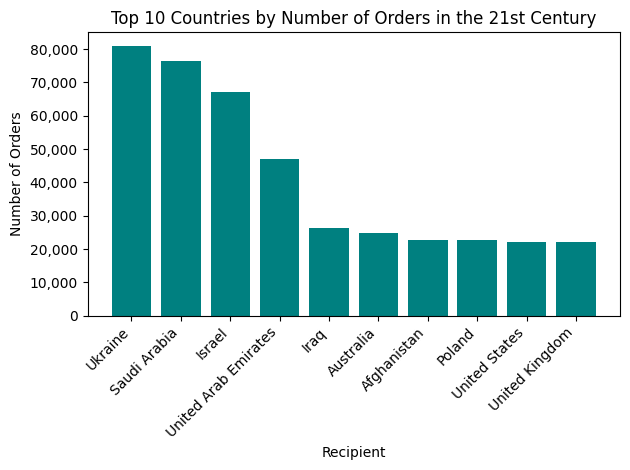

In [26]:
plt.bar(data.index, data.values, color = 'teal')
plt.xlabel('Recipient')
plt.ylabel('Number of Orders')
plt.title('Top 10 Countries by Number of Orders in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()

data visual shows top ten countries with highest count of deliveries

In [27]:
df_this_century.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110913.0
Saudi Arabia,75177.0
United Arab Emirates,46873.0
Israel,46280.0
Iraq,26376.0
Afghanistan,22782.0
United Kingdom,21112.0
United States,18066.0
Egypt,15900.0


In [28]:
data_two = df_this_century.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

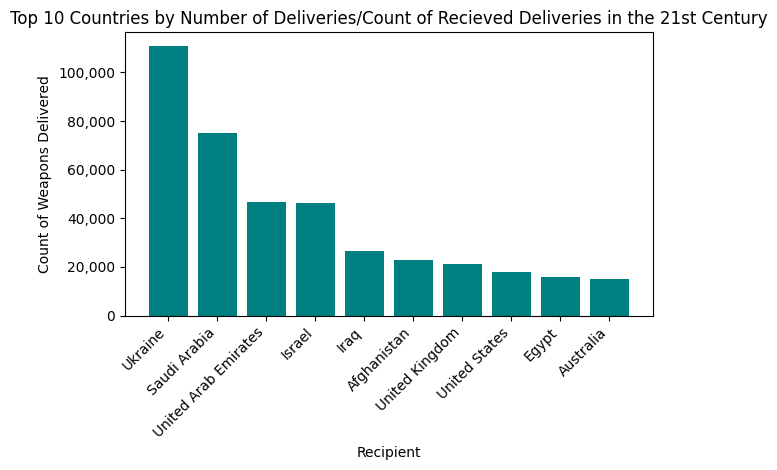

In [29]:
plt.bar(data_two.index, data_two.values, color = 'teal')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Delivered')
plt.title('Top 10 Countries by Number of Deliveries/Count of Recieved Deliveries in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.show()

data visual shows top ten suppliers

In [30]:
df_this_century.groupby('Supplier')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Supplier,
United States,546600.0
Canada,4331.0
Sweden,3210.0
Israel,2592.0
South Africa,2377.0
United Kingdom,2183.0
Germany,620.0
Bulgaria,613.0
Norway,601.0


In [31]:
data_three = df_this_century.groupby('Supplier')['Deliveries in the Year Range'].sum().nlargest(10)

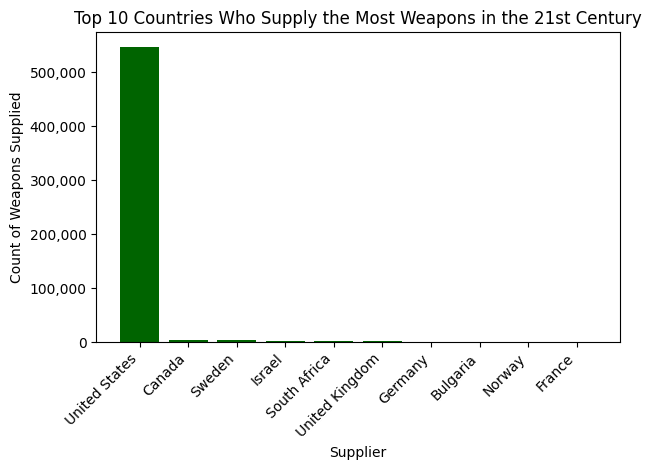

In [32]:
plt.bar (data_three.index, data_three.values, color = 'darkgreen')
plt.xlabel('Supplier')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries Who Supply the Most Weapons in the 21st Century')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()

# US really supplying majority of the major conventional weapons worldwide...
# further visuals: see which top 5 countries is the US sending weapons to (prob Ukraine, Israel, Afghanistan from early 2000s...) -> can filter to last ten years?? 5 years?

 Lets filter to the last five years and see who US supplies the most weapons to

In [33]:
df_last_five = df[df['Year of Order'] >= 2021].sort_values(by='Year of Order', ascending=False)

In [34]:
print (df_last_five['Number Ordered'].mean())
print (df_last_five['Number Ordered'].min())
print (df_last_five['Number Ordered'].max())
print (df_last_five['Deliveries in the Year Range'].mean())
print (df_last_five['Deliveries in the Year Range'].min())
print (df_last_five['Deliveries in the Year Range'].max())

# so when comparing this to this century... we see that there are more orders and more deliveries...

319.0401284109149
1.0
29500.0
424.33125
1.0
29500.0


quick compare to entire df spanning from 1940-present... this is also prob in the . describe we did at the beginning on day 1

In [35]:
print (df['Number Ordered'].mean())
print (df['Number Ordered'].min())
print (df['Number Ordered'].max())
print (df['Deliveries in the Year Range'].mean())
print (df['Deliveries in the Year Range'].min())
print (df['Deliveries in the Year Range'].max())

# ok so the max amount of orders and deliveries was not in the last five years and wasn't in this century either

157.07810234099856
1.0
50000.0
154.80701942685414
1.0
50000.0


heres when the max amount was-- 1958; France to the US

In [36]:
df[df['Number Ordered'] == 50000.0].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
9366,United States,France,1958,50000.0,SS-11,anti-tank missile,50000.0,NaN,New,0.01,500.0,500.0


ok back to vis.. we have to filter so we just see rows where the US was the supplier.. and only in the last five years!!!

In [37]:
df_last_five_US = df_last_five[df_last_five['Supplier'] == 'United States']
df_last_five_US.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
222,Argentina,United States,2025,50.0,Paveway,guided bomb,NaN,NaN,New,0.02,1.0,0.0
243,Australia,United States,2025,400.0,AIM-120D AMRAAM,long-range air-to-air missile,NaN,NaN,New,0.80,320.0,0.0
6235,Poland,United States,2025,8.0,AH-64D Apache Longbow,combat helicopter,8.0,2025.0,Second hand,6.20,49.6,49.6
6276,Poland,United States,2025,NaN,DB-110,aircraft reconnaissance system,NaN,NaN,New,4.00,0.0,0.0
6277,Poland,United States,2025,58.0,APG-83 SABR,combat aircraft radar,NaN,NaN,New,2.50,145.0,0.0


ok now we plot

In [38]:
df_last_five_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110483.0
Israel,11631.0
Australia,1432.0
Poland,1413.0
Greece,1239.0
United Arab Emirates,1106.0
Estonia,888.0
United Kingdom,859.0
France,753.0


In [39]:
data_four = df_last_five_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

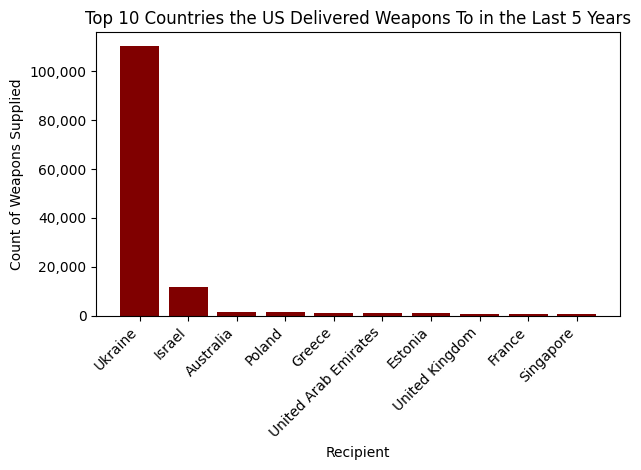

Ukraine 110483.0
Israel 11631.0
Difference 98852.0


In [40]:
plt.bar(data_four.index, data_four.values, color = 'maroon')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries the US Delivered Weapons To in the Last 5 Years')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()
print ("Ukraine", data_four.values[0])
print ("Israel", data_four.values[1])
print ("Difference", data_four.values[0] - data_four.values[1])

compare the number US supplied to Ukraine and Israel with number the world supplied to Ukraine and Israel.. in the last five years as well

In [41]:
df_last_five_world = df_last_five
df_last_five_world.head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
222,Argentina,United States,2025,50.0,Paveway,guided bomb,NaN,NaN,New,0.02,1.0,0.0
243,Australia,United States,2025,400.0,AIM-120D AMRAAM,long-range air-to-air missile,NaN,NaN,New,0.80,320.0,0.0
6235,Poland,United States,2025,8.0,AH-64D Apache Longbow,combat helicopter,8.0,2025.0,Second hand,6.20,49.6,49.6
6276,Poland,United States,2025,NaN,DB-110,aircraft reconnaissance system,NaN,NaN,New,4.00,0.0,0.0
6277,Poland,United States,2025,58.0,APG-83 SABR,combat aircraft radar,NaN,NaN,New,2.50,145.0,0.0


In [42]:
df_last_five_world.groupby ('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Ukraine,110483.0
Israel,11631.0
Australia,1432.0
Poland,1413.0
Greece,1239.0
United Arab Emirates,1106.0
Estonia,888.0
United Kingdom,859.0
United States,858.0


In [43]:
data_five = df_last_five_world.groupby ('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

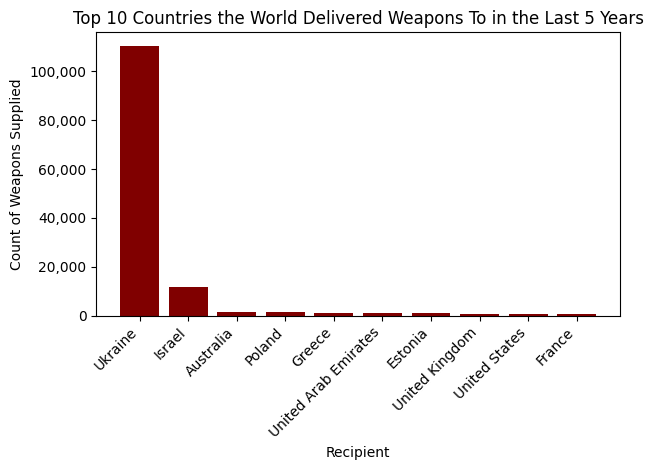

Ukraine 110483.0
Israel 11631.0
Difference 98852.0


In [44]:
plt.bar(data_five.index, data_five.values, color = 'maroon')
plt.xlabel('Recipient')
plt.ylabel('Count of Weapons Supplied')
plt.title('Top 10 Countries the World Delivered Weapons To in the Last 5 Years')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}')) # Format y-axis with thousands separator...
plt.tight_layout()
plt.show()
print ("Ukraine", data_five.values[0])
print ("Israel", data_five.values[1])
print ("Difference", data_five.values[0] - data_five.values[1])

analysis from last two plots: so Ukraine and Israel have high dependancy on US for supply of weapons. According to this dataset, US was the only supplier to these countries in the last five years and therefore makes up all of its weapons that its recieved in last five years...

dfs are filtered correctly so the dataset prob does not reflect that other countries have given weapons to Ukraine and Israel...

Will probably focus on Ukraine and Israel for project..


can look at political party/president and do analysis for both countries

Side Question: did the US (or any country) give any weapons to Ukraine in 2014 after Crimea invasion? Or did Ukraine order weapons from US and then recieve it?

note: data might not be here if ukraine needed to make an order first...
and search said that US did provide aid - but no lethal aid to Ukraine in 2014; so that explains why nothing shows up as well/confirms findings

In [45]:
df[(df['Year of Order']==2014) & (df['Recipient'].isin(['Ukraine']))].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


In [46]:
df[(df['Year of Order']==2014) & (df['Supplier'].isin(['United States'])) & (df['Recipient'].isin(['Ukraine']))].head()

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons


ok now focus on data vis/t-tests with research question..

Potential Research Question: Are U.S. Arms Tranfers to countries in significant global hotspots influenced by who is President and which political party is in office?



# New Section

day 3

Research Question: Are U.S. Arms Tranfers to countries in significant global hotspots influenced by who is President and which political party is in office?

In [47]:
df_last_ten_US = df[(df['Year of Order'] >= 2016) & (df['Supplier'].isin(['United States']))]

In [48]:
df_last_ten_US.groupby('Year of Order')['Deliveries in the Year Range']

In [49]:
data_six = df_last_ten_US.groupby('Year of Order')['Deliveries in the Year Range']

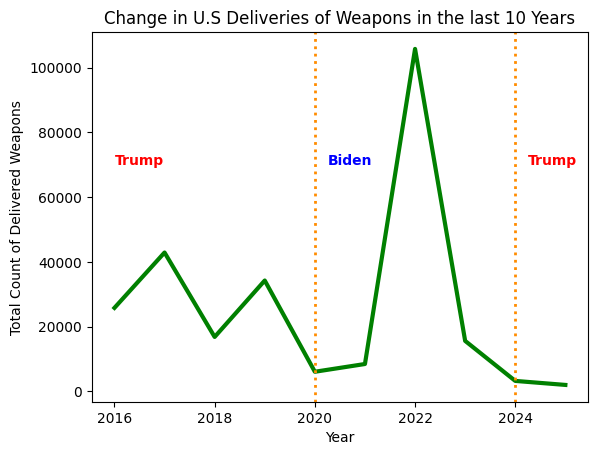

In [76]:
import matplotlib.pyplot as plt

plot_data = data_six.sum()

plt.plot(plot_data.index, plot_data.values, color = 'green', linewidth=3)
plt.xlabel('Year')
plt.ylabel('Total Count of Delivered Weapons')
plt.title('Change in U.S Deliveries of Weapons in the last 10 Years')

plt.axvline(x=2020, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2024, color='darkorange', linestyle=':', linewidth=2)

plt.text(2016, 70000,"Trump", fontsize=10, color="red", weight="bold")
plt.text(2020.25, 70000,"Biden", fontsize=10, color="blue", weight="bold")
plt.text(2024.25, 70000,"Trump", fontsize=10, color="red", weight="bold")



plt.show()

# biden admin delivered more weapons -- but also a lot of conflicts like Russia invasion of Ukraine and IPC started during his admin so this influences result too...

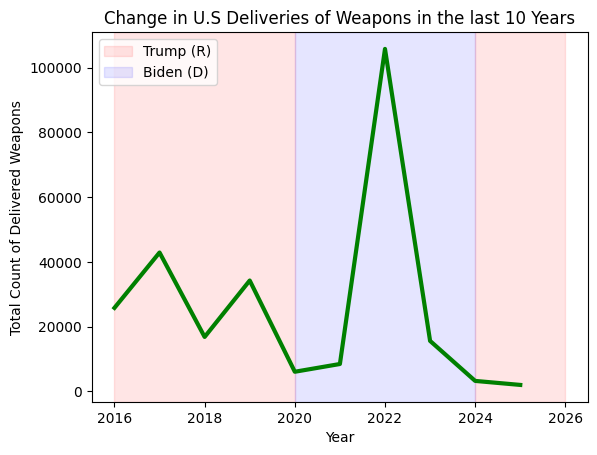

In [80]:
plot_data = data_six.sum()

plt.plot(plot_data.index, plot_data.values, color = 'green', linewidth=3)
plt.xlabel('Year')
plt.ylabel('Total Count of Delivered Weapons')
plt.title('Change in U.S Deliveries of Weapons in the last 10 Years')

plt.axvspan(2016, 2020, color='red', alpha=0.1, label='Trump (R)')
plt.axvspan(2020, 2024, color='blue', alpha=0.1, label='Biden (D)')
plt.axvspan(2024, 2026, color='red', alpha=0.1)

plt.legend()
plt.show()

In [51]:
## can look at 21st century next...

df_this_cent_US = df[(df['Year of Order'] >= 2000) & (df['Supplier'].isin(['United States']))]

In [52]:
df_this_cent_US.groupby('Year of Order')['Deliveries in the Year Range']

In [207]:
df_this_cent_US.groupby('Year of Order')['Number Ordered']

In [53]:
data_seven = df_this_cent_US.groupby('Year of Order')['Deliveries in the Year Range']

In [208]:
data_sev = df_this_cent_US.groupby('Year of Order')['Number Ordered']

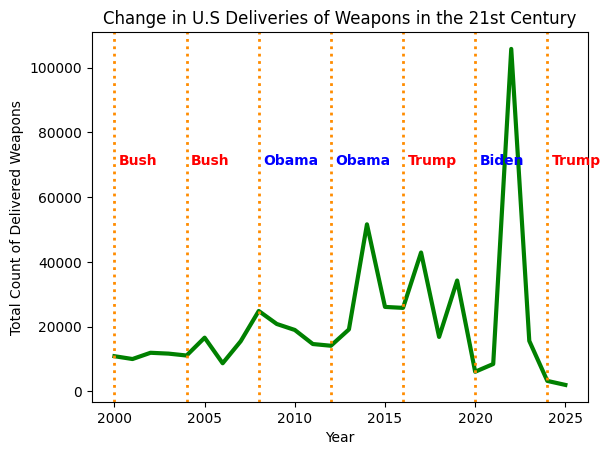

In [209]:
plot_data_two = data_seven.sum()

plt.plot(plot_data_two.index, plot_data_two.values, color = 'green', linewidth=3)
plt.xlabel('Year')
plt.ylabel('Total Count of Delivered Weapons')
plt.title('Change in U.S Deliveries of Weapons in the 21st Century')

plt.axvline(x=2000, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2004, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2008, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2012, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2016, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2020, color='darkorange', linestyle=':', linewidth=2)
plt.axvline(x=2024, color='darkorange', linestyle=':', linewidth=2)

plt.text(2000.25, 70000,"Bush", fontsize=10, color="red", weight="bold")
plt.text(2004.25, 70000,"Bush", fontsize=10, color="red", weight="bold")
plt.text(2008.25, 70000,"Obama", fontsize=10, color="blue", weight="bold")
plt.text(2012.25, 70000,"Obama", fontsize=10, color="blue", weight="bold")
plt.text(2016.25, 70000,"Trump", fontsize=10, color="red", weight="bold")
plt.text(2020.25, 70000,"Biden", fontsize=10, color="blue", weight="bold")
plt.text(2024.25, 70000,"Trump", fontsize=10, color="red", weight="bold")


plt.show()

## try shading these graphs instead of divider lines

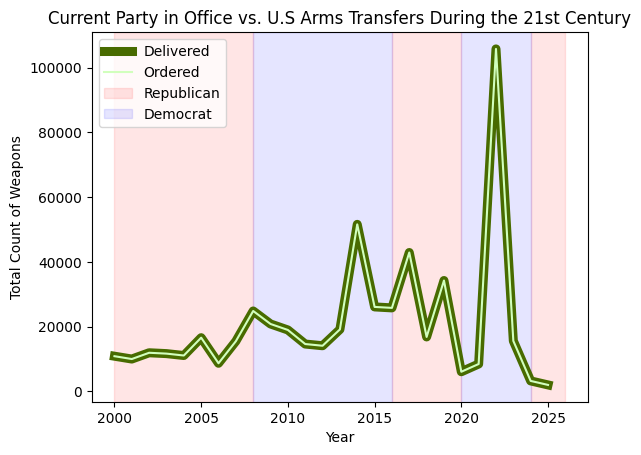

In [233]:
plot_data_two = data_seven.sum()
plot_dat = data_sev.sum()

plt.plot(plot_dat.index, plot_data_two.values, color = '#486B00', linewidth=6.5, label = "Delivered")
plt.plot(plot_dat.index, plot_data_two.values, color = '#D1FFBD', linewidth=1.5, label = "Ordered")

plt.xlabel('Year')
plt.ylabel('Total Count of Weapons')
plt.title('Current Party in Office vs. U.S Arms Transfers During the 21st Century')

# Republican terms
plt.axvspan(2000, 2008, color='red', alpha=0.1, label='Republican') # George W. Bush
plt.axvspan(2016, 2020, color='red', alpha=0.1) # Donald Trump
plt.axvspan(2024, 2026, color='red', alpha=0.1) # Donald Trump

# Democratic terms
plt.axvspan(2008, 2016, color='blue', alpha=0.1, label='Democrat') # Barack Obama
plt.axvspan(2020, 2024, color='blue', alpha=0.1) # Joe Biden

#plt.text(2000.25, 5000,"Bush", fontsize=10, color="red", weight="normal")
#plt.text(2008.25, 0,"Obama", fontsize=10, color="blue", weight="normal")
#plt.text(2016.25, 5000,"Trump", fontsize=10, color="red", weight="normal")
#plt.text(2020.25, 0,"Biden", fontsize=10, color="blue", weight="normal")
#plt.text(2024.25, 5000,"Trump", fontsize=10, color="red", weight="normal")
plt.legend()
plt.show()

In [248]:
df_this_cent_US[df_this_cent_US['Number Ordered'] != df_this_cent_US['Deliveries in the Year Range']].head()

# five where deliveries were less than orders -- but we only have full data for two/five entries...

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
33,Albania,United States,2022,50.0,FGM-148 Javelin,anti-tank missile,25.0,2025.0,New,0.03,1.5,0.75
53,Algeria,United States,2023,6.0,aircraft engine,aircraft engine,NaN,NaN,New,0.50,3.0,0.00
66,Angola,United States,2023,4.0,FJ44-4,turbofan,NaN,NaN,New,0.60,2.4,0.00
68,Argentina,United States,2025,2.0,King Air Maritime,maritime patrol aircraft,NaN,NaN,New,7.50,15.0,0.00
76,Argentina,United States,2022,6.0,Bell-407,light helicopter,5.0,NaN,New,1.30,7.8,6.50


above graphs gives us general info about presidents/political parties and their relationship to delivering weapons. political parties cannot be summed up or limited in this way though and there are prob many other factors influencing US decisions, esp for Biden...

next step... take closer look at Ukraine and IPC as global hotspots...

In [55]:
df_five_US_Ukraine = df[(df['Year of Order'] >= 2021) & (df['Supplier'].isin(['United States'])) & (df['Recipient'].isin(['Ukraine']))]
df_five_US_Israel = df[(df['Year of Order'] >= 2021) & (df['Supplier'].isin(['United States'])) & (df['Recipient'].isin(['Israel']))]

In [56]:
df_five_US_Ukraine.groupby('Year of Order')['Deliveries in the Year Range']
df_five_US_Israel.groupby('Year of Order')['Deliveries in the Year Range']

In [57]:
data_eight = df_five_US_Ukraine.groupby('Year of Order')['Deliveries in the Year Range']
data_nine = df_five_US_Israel.groupby('Year of Order')['Deliveries in the Year Range']

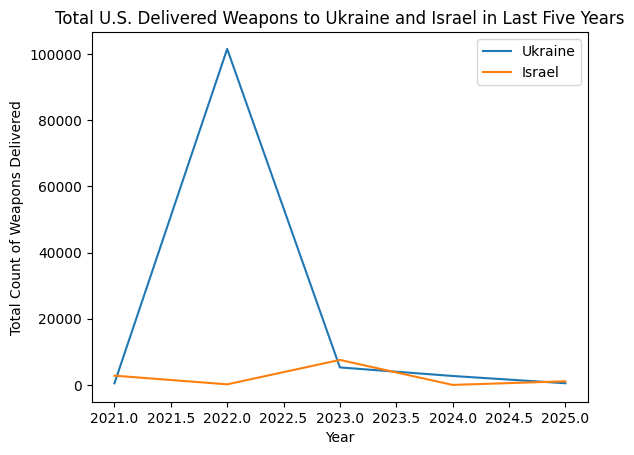

In [133]:
plt.plot (data_eight.sum().index, data_eight.sum().values, label = "Ukraine")
plt.xlabel ('Year')
plt.ylabel ('Total Count of Weapons Delivered')
plt.title('Total U.S. Delivered Weapons to Ukraine in Last Five Years')

plt.plot (data_nine.sum().index, data_nine.sum().values, label = "Israel")
plt.xlabel ('Year')
plt.ylabel ('Total Count of Weapons Delivered')
plt.title('Total U.S. Delivered Weapons to Ukraine and Israel in Last Five Years')



## add a legend...
plt.legend()

 data is pretty limited for Ukraine and IPC hotspots..

can look at other recipients..

In [59]:
df_cent_US = df[(df['Year of Order'] >= 2000) & (df['Supplier'].isin(['United States']))]

Text(0.5, 1.0, 'Top 10 Countries the U.S Delivered Weapons to in 21st Century')

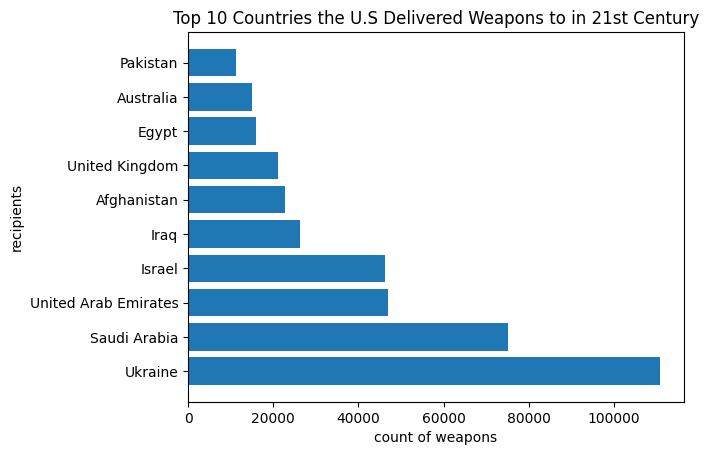

In [60]:
plot_info = df_cent_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)
plt.barh (plot_info.index, plot_info.values)
plt.xlabel ('count of weapons')
plt.ylabel ('recipients')
plt.title('Top 10 Countries the U.S Delivered Weapons to in 21st Century')

# can explore UAE, Saudi Arabia

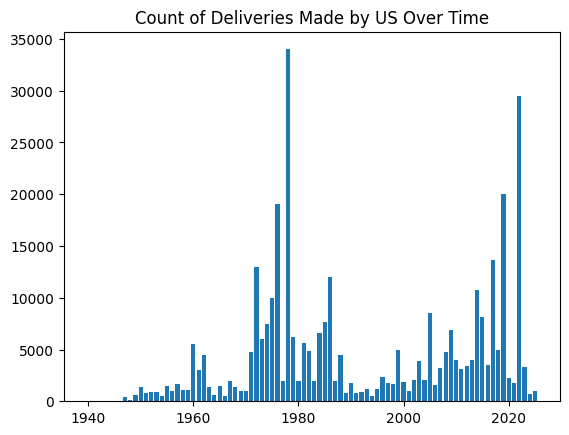

In [61]:
df_US = df[df['Supplier'] == 'United States']
plt.bar(df_US['Year of Order'], df_US['Deliveries in the Year Range'])
plt.title('Count of Deliveries Made by US Over Time')
## shift x axis so graph is not skewed...
# add axis
plt.show()
# definitely a lot happening during cold war with US as the supplier.. can explore that

In [62]:
df_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

,Deliveries in the Year Range
Recipient,
Saudi Arabia,121738.0
Ukraine,110913.0
Israel,84732.0
United Kingdom,75690.0
Germany,74381.0
United Arab Emirates,51237.0
Turkiye,50733.0
Iran,50662.0
Italy,50591.0


In [63]:
data_twelve = df_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)

Text(0.5, 1.0, 'Top 10 Countries the U.S Delivered Weapons to')

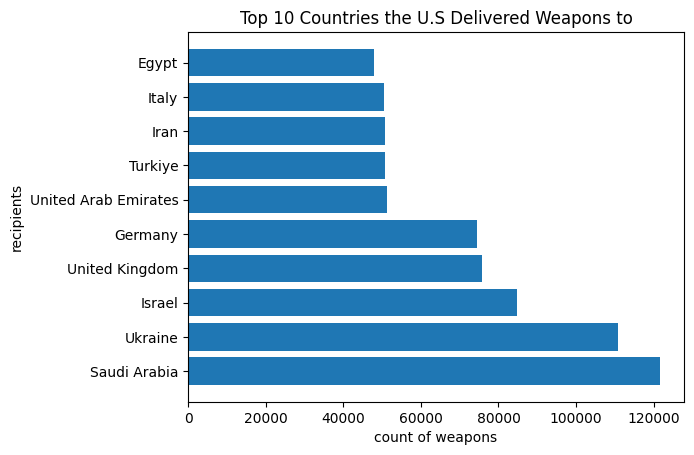

In [64]:
plt.barh(data_twelve.index, data_twelve.values)
plt.xlabel ('count of weapons')
plt.ylabel ('recipients')
plt.title('Top 10 Countries the U.S Delivered Weapons to')

# can explore UAE, Saudi Arabia

cold war ---->

In [157]:
df_cold_war = df[(df['Year of Order'] >= 1950) & (df['Year of Order'] <= 1997) & (df['Supplier'].isin(['United States']))]

In [158]:
df_cold_war.describe()

,Year of Order,Number Ordered,Deliveries in the Year Range,Year(s) of delivery,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,6088.000000,6088.000000,6088.000000,3307.000000,6088.000000,6088.000000,6088.000000
mean,1973.442181,125.690046,125.689060,1974.244330,6.992142,89.032720,89.032227
std,13.236917,731.351365,731.351487,13.199188,20.861992,321.774362,321.774472
min,1950.000000,1.000000,1.000000,1950.000000,0.000000,0.040000,0.040000
25%,1962.000000,3.000000,3.000000,1963.000000,0.250000,5.000000,5.000000
50%,1974.000000,10.000000,10.000000,1974.000000,1.050000,18.400000,18.400000
75%,1984.000000,50.000000,50.000000,1984.000000,5.250000,56.000000,56.000000
max,1997.000000,34000.000000,34000.000000,2008.000000,385.000000,10117.500000,10117.500000


In [159]:
df_cold_war['Recipient'].value_counts()

,count
Recipient,
Taiwan,257
Japan,252
South Korea,251
Thailand,220
Turkiye,216
...,...
Saint Kitts and Nevis,1
Qatar,1
Papua New Guinea,1


In [160]:
df[(df['Year of Order'] == 1978) & (df['Deliveries in the Year Range'] == 34000)]
# this is the max number of deliveries supplied by the US in the Cold War

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
9138,United Kingdom,United States,1978,34000.0,BGM-71 TOW,anti-tank missile,34000.0,NaN,New,0.01,340.0,340.0


In [161]:
df_US.describe()
# more info...

,Year of Order,Number Ordered,Deliveries in the Year Range,Year(s) of delivery,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
count,9432.000000,9353.000000,9027.000000,4778.000000,9432.000000,9432.000000,9432.000000
mean,1986.929389,149.914145,147.586241,1985.875889,7.480077,91.768489,81.303185
std,22.117583,841.683249,848.447344,21.614437,23.796364,331.598051,296.476280
min,1940.000000,1.000000,1.000000,1950.000000,0.000000,0.000000,0.000000
25%,1969.000000,3.000000,3.000000,1968.000000,0.227500,5.000000,4.190000
50%,1985.000000,12.000000,12.000000,1983.000000,1.000000,18.000000,15.720000
75%,2007.000000,60.000000,57.000000,2005.000000,5.000000,56.000000,51.000000
max,2025.000000,34000.000000,34000.000000,2025.000000,700.000000,10117.500000,10117.500000


In [162]:
df_cold_war.groupby('Year of Order')['Deliveries in the Year Range'].sum()

,Deliveries in the Year Range
Year of Order,
1950,8771.0
1951,8463.0
1952,5827.0
1953,4608.0
1954,6468.0
1955,11675.0
1956,6783.0
1957,6821.0
1958,10272.0


In [163]:
plot_data = df_cold_war.groupby('Year of Order')['Deliveries in the Year Range'].sum()

In [234]:
data = df_cold_war.groupby('Year of Order')['Number Ordered'].sum()

Text(0.5, 1.0, 'US Weapons Deliveries Count during the Cold War')

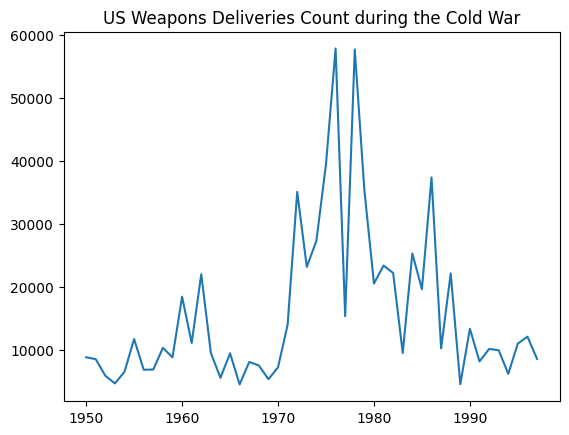

In [164]:
plt.plot (plot_data.index, plot_data.values)
plt.title ('US Weapons Deliveries Count during the Cold War')

In [72]:
## can do a graph that shows delivery count among different conflicts (like with Ukraine and Israel but during Cold War period... a lot of filtering tho)

## for day 4, continue focusing on visual showing presidential terms over delivery count (for all conflicts, for Ukraine, for Israel, for Cold War)
                                                                                          ## can filter cold war to top three country recipients !!
                                                                                          ## can do Ukraine and Israel for 21st century !!
## and continue doing lit review to get better idea of how weapon deliveries are impacted by who is president/by the political party in office

## for ML phase, can add a row with 1 or 0 (Dem or Rep) and see what they predict based on number of weapons delivered...

# New Section

Day 4

Goals:

1. Fix up data visuals from yesterday

- shifting over x axis on that one graph

- legend

- shading over line OR different colors on line


2. Make Cold War line plot from end of day 3 with shading divisions for POTUS OR different colors on lines

3. make a graph that shows US Supply to Ukraine and Israel in the 21st Century - just to see

4. make a big graph/line plot comparing Ukraine, Israel, and Cold War and maybe label on this map when the conflict started and stopped/still going/where things improved/got worse... - this is based on outside resources tho...
- first make a line plot to see US supply to top countries in Cold War; if country gets weapons for a long period/or for reasons that seems like it relates to the Cold War - outside research - then include it in the filtered_cold_war df... and use this df for cold war graph.... ---> idk tho.. ***maybe just do all the countries that recieved weapons from the US during the Cold War..***.

also....

- plan to maybe do a t test comparing Ukraine v Israel delivered weapons; Cold War v Ukraine delivered weapons; but review all t test material to do tests correctly...

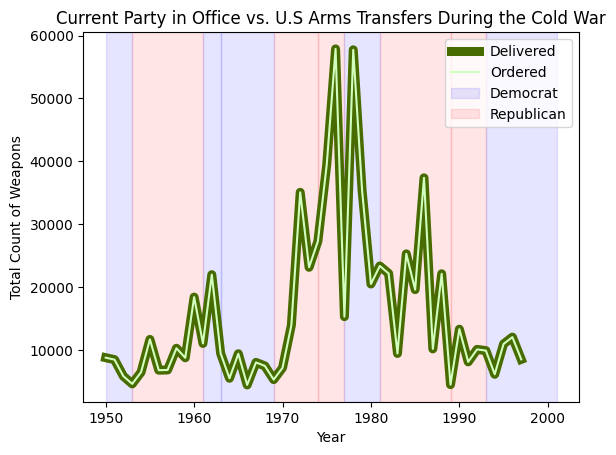

In [251]:
plt.plot (plot_data.index, plot_data.values, color = '#486B00', linewidth=6.5, label = "Delivered")
plt.plot (data.index, data.values, color = '#D1FFBD', linewidth = 1.5, label = "Ordered")

plt.xlabel('Year')
plt.ylabel ('Total Count of Weapons')
plt.title ('Current Party in Office vs. U.S Arms Transfers During the Cold War')

plt.axvspan(1950, 1953, color='blue', alpha=0.1, label='Democrat')
plt.axvspan(1953, 1961, color='red', alpha=0.1, label='Republican')
plt.axvspan(1961, 1963, color='blue', alpha=0.1)
plt.axvspan(1963, 1969, color='blue', alpha=0.1)
plt.axvspan(1969, 1974, color='red', alpha=0.1)
plt.axvspan(1974, 1977, color='red', alpha=0.1)
plt.axvspan(1977, 1981, color='blue', alpha=0.1)
plt.axvspan(1981, 1989, color='red', alpha=0.1)
plt.axvspan(1989, 1993, color='red', alpha=0.1)
plt.axvspan(1993, 2001, color='blue', alpha=0.1)

plt.legend()


plt.show()

##Harry S. Truman (Democrat) — Served from 1945 to 1953
##Dwight D. Eisenhower (Republican) — Served from 1953 to 1961
##John F. Kennedy (Democrat) — Served from 1961 to 1963
##Lyndon B. Johnson (Democrat) — Served from 1963 to 1969
##Richard Nixon (Republican) — Served from 1969 to 1974
##Gerald Ford (Republican) — Served from 1974 to 1977
##Jimmy Carter (Democrat) — Served from 1977 to 1981
##Ronald Reagan (Republican) — Served from 1981 to 1989
##George H.W. Bush (Republican) — Served from 1989 to 1993
##Bill Clinton (Democrat) — Served from 1993 to 2001

# Note: deliveries during this cold war era does not necessarily mean the deliveries were part of cold war strategies
# but most of them prob were because of the top countries that recieved weapons from US (see above) -- mostly surrounding Soviet Union.../hotspots at the time

In [254]:
df_this_cent_US.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3105 entries, 0 to 9753
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       3105 non-null   object 
 1   Supplier                        3105 non-null   object 
 2   Year of Order                   3105 non-null   int64  
 3   Number Ordered                  3026 non-null   float64
 4   Weapon Designation              3105 non-null   object 
 5   Weapon Description              3105 non-null   object 
 6   Deliveries in the Year Range    2700 non-null   float64
 7   Year(s) of delivery             1344 non-null   float64
 8   Status                          3105 non-null   object 
 9   SIPRI TIV per unit              3105 non-null   float64
 10  SIPRI TIV for total order       3105 non-null   float64
 11  SIPRI TIV of delivered weapons  3105 non-null   float64
dtypes: float64(6), int64(1), object(5)
memo

In [253]:
df_cold_war.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6088 entries, 38 to 9755
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Recipient                       6088 non-null   object 
 1   Supplier                        6088 non-null   object 
 2   Year of Order                   6088 non-null   int64  
 3   Number Ordered                  6088 non-null   float64
 4   Weapon Designation              6088 non-null   object 
 5   Weapon Description              6088 non-null   object 
 6   Deliveries in the Year Range    6088 non-null   float64
 7   Year(s) of delivery             3307 non-null   float64
 8   Status                          6088 non-null   object 
 9   SIPRI TIV per unit              6088 non-null   float64
 10  SIPRI TIV for total order       6088 non-null   float64
 11  SIPRI TIV of delivered weapons  6088 non-null   float64
dtypes: float64(6), int64(1), object(5)
mem

In [247]:
df_cold_war[df_cold_war['Number Ordered'] != df_cold_war['Deliveries in the Year Range']].head()
# only 1 entry where US delivered less than what was ordered ...

,Recipient,Supplier,Year of Order,Number Ordered,Weapon Designation,Weapon Description,Deliveries in the Year Range,Year(s) of delivery,Status,SIPRI TIV per unit,SIPRI TIV for total order,SIPRI TIV of delivered weapons
3147,Indonesia,United States,1990,38.0,aircraft engine,aircraft engine,32.0,NaN,New,0.5,19.0,16.0


Text(0.5, 1.0, 'Top 10 Countries the U.S Delivered Weapons to in 21st Century')

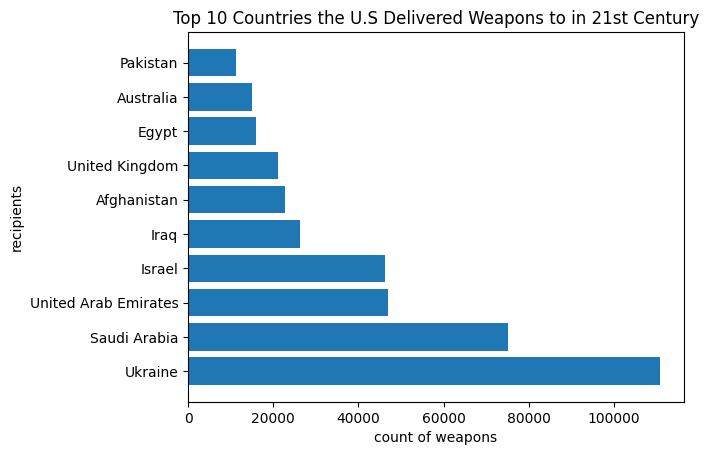

In [131]:
plot_info = df_cent_US.groupby('Recipient')['Deliveries in the Year Range'].sum().nlargest(10)
plt.barh (plot_info.index, plot_info.values)
plt.xlabel ('count of weapons')
plt.ylabel ('recipients')
plt.title('Top 10 Countries the U.S Delivered Weapons to in 21st Century')

can make a visual on countries in top graph

can focus just on Ukraine and Israel in last five years... and show political divides... - we did this already above.. different pres. terms can be discerned



In [ ]:
# end of day 4-

# will shift towards a new research question; old one would give biased results because of data and nature of question
# new research question will focus on how U.S. support for Ukraine and Israel is similar/different over last five years
# new research should go in new colab notebook; both still linked in same github
# new research can have a classification model -- but mostly just for confirmation after data vis and t-tests
# and if doing classification model, can use feature importance to make further relationship conclusions